# Voltammetry: part 1

```{admonition} How To Work
:class: important
The **Preparatory Homework (BAS)** part of this manual should be completed **individually**.

The **Practicum (IC)** part should be completed **in pairs**. During the practicum, divide the workload as equally as possible, for example by letting one student build one part of the circuit while the other student builds a different part, or works on troubleshooting or the code. 

Throughout this manual, keep your calculations, measurements, sketches, and thoughts in your log book entry. Relevant definitions in Background, your answers to the questions in the Anticpiate section, findings during Implement and Investigate and your conclusions should be included in your one page report.

Download the entry from the download menu at the top of this page, under **Log book**. Complete the **Preparation** side before the practicum, then fill in the **Practicum** side at the bench. The PDF has interactive fields, so you can either type into it or print it and write by hand. If you would rather draw the sketches or add a photo than print the entry, open it in [pdfannotation.app](https://pdfannotation.app/), which handles form filling, drawing and images together.

## Preparatory Homework

### Background
```{admonition} Preparation
:class: tip
The last experiment will be slightly larger than you are used to. The two coming notebooks will focus mostly on the practical side of conducting a voltammetry experiment, please make yourself familiar with the background of this type of experiment by reading chapter 9.3 of the textbook:

* [Textbook chapter 9.3: Voltammetry](https://interactivetextbooks.tudelft.nl/dev/electronic-instrumentation/content/10_complex_systems.html#voltammetry)


During this week you will be given a lot of freedom to make your own choices. There is not one way that is inherently better than others. What matters is that you have thought about the different options and come up with a well founded experiement and hopefully a nice result!
```
(Task_B1_8_1)=
#### Task B1: General setup
During a voltammetry experiment you are interested in the relation between the current produced when applying a voltage across a measurement cell. This means your final setup will consist of three steps:

1. Controlling $U_{\text{cell}}$
2. Controlling $I_{\text{cell}}$-to-$U_{\text{a}}$ conversion
3. Measuring $U_{\text{a}}$

As you can see **step 2** has already been laid out in the figure below. 
```{figure} figures/Voltammetry_stripped.png
---
name: fig-heart-voltammetry
height: 400px
---
The heart of your Voltammetry setup with the real measurement cell replaced by two resistors.
```

Note that this setup neither specifies exaclty how $U_{\text{cell}}$ is controlled, nor how $U_{\text{a}}$ is measured. During this assigment you will carefully consider the different options to conduct these steps and come up with a robust measuring procedure that you can use during the next assignement. That is why the measurement cell has ,for now, been replaced by resistors $R_1$ and $R_2$. In the next session these will be replaced by a real sensor, but in order to make testing easier this simplification is used.

### Anticipate

In order to help you make a concious decision on how to best conduct this experiment, you must first understand the curcuit. Then you will have to explore different options to generate your voltage and read out the resulting signal. Lastly you shall design and test a measurement procedure including writing code for data aquisition and analysis. The last part will be done during the lab session.


(Task_A1_8_1)=
#### Task A1: Understand the circuit
```{admonition} Estimated time: 15 min
:class: estimated-time no-content
```

Using the well known rules for opamps to answer the following questions:
1. What will be the voltage between resistor $R_1$ and $R_2$?

2. What will be the voltage across $R_2$, a.k.a $U_{\text{cell}}$?

3. What is the function of $R_f$ and how do you choose its value wisely?

4. Formulate a formula for the output voltage. 



```{admonition} Check your answer
:class: answer, dropdown
1.  $U_{\text{dacA}}$
2.  $U_{\text{dacB}}\quad -U_{\text{dacA}}$
3.  To convert $I_{cell}$ into a measurable voltage. It determines how large the output voltage is going to be, which is bound by clipping of the opamp.
4.  $U_a=I_{cell} \cdot R_f = \frac{U_{\text{dacB}}\quad - U_{\text{dacA}}\quad}{R_2} \cdot R_f$
```

(Task_A2_8_1)=
#### Task A2: Exploring options to generate and measure voltages
```{admonition} Estimated time: 30 min
:class: estimated-time no-content
```
A voltammetry experiment needs $U_{cell}$ to sweep across both positivie as well as negative voltages. The resulting output will not surpsisingly also cover a similar range. This is exaclty where the main difficulty of this project lies. The ALPACA can only operate with voltages ranging from **0 to 3V**, so you will have to find a way to work around this constraint. 

1. Can you give two reasons why it would be benefical to make use of as much of this range as possible?

Conceptually the easiest version requires DAC B to be set on 0V, effectively functioning as a ground point. 

2. How would you generate a voltage sweep that is still able to cover negative voltages, using the features the ALPACA offers?

3. Same question for measuring the output signal.

4. What disadvantages does this setup bring in terms of SNR, difficulties during data analysis etc.?


```{admonition} Hints
:class: hint, dropdown
1. Think of two factors that introduce error in your setup or see [ALPACA manual](../intros/alpaca2/signals.ipynb)
2. DAC assistent maybe?
3. You could use two adc's
4. Think what happens if the output hits exaclty 0V
```

A different path can be chosen by applying a constant voltage to DAC B. 

1. What is the main advantage of having DAC B at a certain offset?
   
2. What will be the main difficulty you will face during testing?


```{admonition} Hints
:class: hint, dropdown
1. Remember: $U_{cell} = U_{\text{dacB}}-U_{\text{dacA}}$
2. How are you going to choose your values for DAC A, DAC B and $R_f$?
```





(Task_A3_8_1)=
#### Task A3: Attenuation setting
```{admonition} Estimated time: 10 min
:class: estimated-time no-content
```

No matter how your design is going to look like, you will always need to attenuate your output signal before you measure with the ALPACA. By doing this you effectively can expand the 0 to 3V range to a range that is more to your liking. 

1. What will be the inevitable limiting factor on your output voltage?

2. What would be the ideal attenuation setting?

```{admonition} Hints
:class: hint, dropdown
1. The output voltage comes directly from the output of an opamp
2. Yes 10x will work but can you think of a way to get any attenuation you would like ($R_{ext}$)?
```

### Simulate

```{attention}
The simulations below confirm your hand calculations from Anticipate before you touch the breadboard. If a sim disagrees with your prediction, find the bug **on paper** before you build the circuit. Catching mistakes here saves a lot of debugging time at the bench.
```


(Task_S3_4_1)=
#### Task S1: Simulate the simplified voltammtery circuit
```{admonition} Estimated time: 15 min
:class: estimated-time no-content
```

In order to save you some time, you can download the LTSpice file from brightspace containing the full circuit as shown in figure [8.1](fig-heart-voltammetry). There will be no direct tasks here but feel free to make yourself familiar with the circuit before you actully build it. Try different values for $R_f$, $U_{dacB}$ while keeping $R_1$ and $R_2$ equal to 10k. See what happens if you sweep $U_{dacA}$ across different ranges. If you familiar enough with the circuit you can continue to the practical part.

## Practicum

### Implement and investigate

During the practicum, work in pairs and divide the practical work as equally as possible. Five practical tasks are scheduled below; assemble the first circuit carefully together, then alternate between "builder" and "scope operator" for the next ones. Both students should always be in agreement about what the circuit on the breadboard looks like before the supply is switched on.

```{attention}
Always wire the $\pm 12\,\mathrm{V}$ supply with the supply **off**. Verify the polarity at pin 8 (positive) and pin 4 (negative) with the DMM before connecting the chip. Reversing the rails will destroy the opamp within seconds.
```


(Task_I1_8_1)=
#### Task I1: Know your enemy
```{admonition} Estimated time: 30 min
:class: estimated-time no-content
```

Do not build the circuit just yet. Before starting testing your setup it is important to know what you are up against. Noise will for a large part determine how good your measurement will be in the end. That is why the first test will consist of a measuring the intrinsic noise in your system.

1. Measure all three adc's simultaneously with nothing attached to them

2. Calculate the mean and standard deviation of your signal


In order to see how these sources introduce error into your setup you could use DAC A to generate a linear voltage sweep from 0 to 3V and again measure with all adc's.

3. Write down what you observe and what this means if you are going to measure with two adc's.

There are various ways of reducing the influence of noise in your system. Two ways are proposed here and it is up to you to figure out a way to implement them.

* Low-pass filter using a capacitor and $R_f$. Carefully choose the values for $R_f$ and $C$ in order to have a beneficial cut-off frequency.

* Averaging, but what will that do to the timing of your data aquisition?


(Task_I2_8_1)=
#### Task I2: Build and test the circuit
```{admonition} Estimated time: 60 min
:class: estimated-time no-content
```
After completing all previous task you should now have all the the tools the build the circuit below and start testing your idea's. You have the freedom to test everything you'd like. Start with a simple signal generation/aquisition and keep $R_1$ and $R_2$ on 10k, tune the gain/attenuation settings and $R_f$ in order to get a good signal that can be turned into a voltammogram (it should look like a straight line). After that you can start experimenting with averaging, different timing settings, low-pass filtering, etc. Feel free to use anything on the board and the osciloscope if you want. 

```{figure} figures/Voltammetry_with_C.png
---
name: fig-non-inverting-amp
height: 350px
---
The heart of your Voltammetry setup with the real measurement cell replaced by two resistors. A capacitor has been added to suppress high frequency noise. 
```


(Task_I3_8_1)=
#### Task I3: Design a robust measurment procedure
```{admonition} Estimated time: 30 min
:class: estimated-time no-content
```


During a real experiment time efficiency of of the utmost impartance. That is why before you start the next session, you are encouraged to come up with a measuremnt plan that you can stick to during the day of the experiment. That means your procuderes should leave room for adaptations if things are not behaving the way you expect them to. Make sure to include:

* The values you have chosen for $R_f$, DAC B and $C$
* How are you going to perform the sweep with DAC A?
* How are you going to measure the outgoing signal?
* What are you going to do if your signal is too small/large?
* How are you going to perform data analysis?

Besides writing down the steps of your measurement procedure it is recommended to write a .py or .ipynb file that will serve as the base for your experiment next session. 


Now you have the opporunity to test your procedure by elevating your model for the measurement cell with a non-linear component such as a multiple diodes, LED's or a Zener diode. If your setup is able to capture the complete non-linear behaivior of your omponent of choice you are done for today and you can head to [Compare and Conclude](Task_C1_8_1)
```{figure} figures/Zener.png
---
name: fig-non-inverting-amp
height: 350px
---
Example of a non-linear model for your measurement cell. 
```


### Compare and Conclude


(Task_C1_8_1)=
#### Task C1: What is your design philosophy?
```{admonition} Consider Tasks [A1](Task_A1_8_1), [A2](Task_A2_8_1), [I1](Task_I1_8_1)
:class: note no-content
```
During this assignment you have hopefully gotten a good idea of how your voltammetry setup works. Share with the TA which choices you made and their advantages and disadvantages.
(Task_C1_8_1)=
#### Task C2: How will the next session look like?
```{admonition} Consider Tasks [I2](Task_I2_8_1), and [I3](Task_I3_8_1).
:class: note no-content
```

Share with the TA your written measurement plan for the next session. 

```{admonition} Deep dive: Adding hysteres through a parallel capacitor
:class: deep-dive, dropdown
You could make the model for the measurment cell even more realistic by adding a capacitor with an unknown value parallel to $R_2$.
```

In [20]:

import numpy as np
matplotlib.use("module://ipympl.backend_nbagg")
%matplotlib widget

from belay import Device
from alpaca import list_boards

# 'list_boards()' gets all connected boards to your computer
# and the first element is most likely the ALPACA. 

#plt.ion()
pico = Device(list_boards()[0].to_port())

In [21]:

import matplotlib.pyplot as plt

In [22]:
plt.plot([], [])

In [23]:
@pico.task
def update_screen1():
    import helper
    helper.set_screen_text("Hello","World!")
@pico.task
def update_screen2():
    import helper
    helper.set_screen_text("Bye")
update_screen1()


In [24]:
update_screen2()

In [115]:
@pico.task
def setup():
    from machine import Pin, ADC
    from dac import DAC
    global dac_a
    dac_a = DAC("A")
    global dac_b
    dac_b = DAC("B")
    global adc_1 
    adc_1 = ADC(27)
    global adc_0 
    adc_0 = ADC(26)
    global adc_2 
    adc_2 = ADC(28)
@pico.task
def sine_wave():
    import math
    import utime
    vals=[]
    with dac_a.generate(
       lambda t: 3/2 * (math.sin(t * 2 * math.pi) + 1),
       frequency_hz=1,
       N=500):
        utime.sleep(6.5)
        for i in range(500):
            vals.append(adc_0.read_u16())
            utime.sleep(0.01)
    dac_a.write(0)
    return vals
@pico.task
def do_ramp(N):
    import utime
    vals_0=[]
    vals_1=[]
    vals_2=[]
    dac_a.write(0)
    dac_b.write(2)
    utime.sleep(0.5)
    n=5
    start = utime.ticks_ms()
    for v in range(N):
        dac_a.write(v/N*2.5)
      #  dac_b.write(-v/N/5*3+2.048)
        utime.sleep(0.004)
        sum=[0,0,0]
        for i in range(n):
            sum[0]+=adc_0.read_u16()
            sum[1]+=adc_1.read_u16()   
            sum[2]+=adc_2.read_u16()
        vals_0.append(sum[0]/n/65535*3)
        vals_1.append(sum[1]/n/65535*3)
        vals_2.append(sum[2]/n/65535*3)
        utime.sleep(0.004)
    for v in range(N):
            dac_a.write(2.7-v/N*2.5)
          #  dac_b.write((-1+v/N)*3/5+2.048)
            utime.sleep(0.004)
            sum=[0,0,0]
            for i in range(n):
                sum[0]+=adc_0.read_u16()
                sum[1]+=adc_1.read_u16()    
                sum[2]+=adc_2.read_u16()
            vals_0.append(sum[0]/n/65535*3)
            vals_1.append(sum[1]/n/65535*3)
            vals_2.append(sum[2]/n/65535*3)
            utime.sleep(0.004)
    elapsed = utime.ticks_diff(utime.ticks_ms(), start)
    print(5/elapsed*1000,"V/s")
    dac_a.write(0)
    dac_b.write(0)
    return vals_0,vals_1,vals_2
@pico.task
def set_voltage(voltage):
    dac_a.write(voltage)
@pico.task
def measure_voltage():
    return adc_0.read_u16(), adc_1.read_u16()


In [129]:
0.4/2500/5.3

3.0188679245283022e-05

In [116]:
setup()
set_voltage(0)

In [134]:
setup()

meas=do_ramp(50)
# meas=sine_wave()

5.938242 V/s


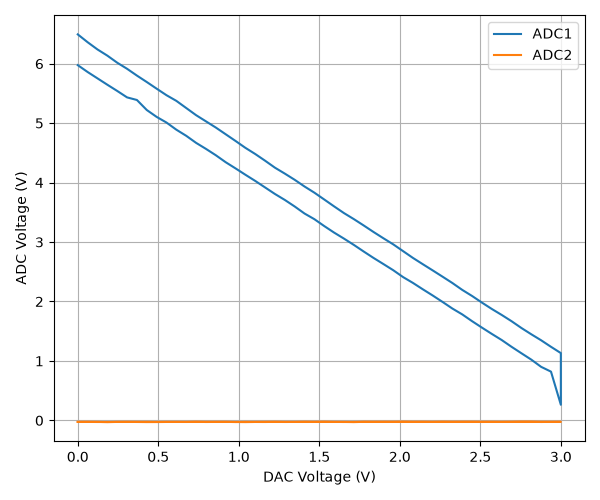

In [135]:
meas=np.array(meas)
plt.figure(figsize=(6,5))
x_vals=np.linspace(0,3,len(meas[0])//2)
x_vals=np.append(x_vals,x_vals[::-1])
#plt.plot(x_vals,meas[0]/65535*3,label="ADC0")
plt.plot(x_vals,meas[1]*10,label="ADC1")
plt.plot(x_vals,meas[2]*-1, label="ADC2")
#plt.plot(x_vals,meas[1]*-10-meas[2],label="total")
plt.grid()

plt.xlabel("DAC Voltage (V)")
plt.ylabel("ADC Voltage (V)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
setup()
@pico.task
def helper_dac(N,frequency=3):
    import helper
    import utime
    with helper.function_generator.sine(frequency,3):
        utime.sleep(1)
        vals1=[]
        vals2=[]
        for i in range(N):
            sum1=0
            sum2=0
            for i in range(3):
                sum1+=adc_1.read_u16()
                sum2+=adc_2.read_u16()
            vals1.append(sum1/3/2**16*3)
            vals2.append(sum2/3/2**16*3)
            utime.sleep(0.001)
    return vals1,vals2


In [ ]:
maximums=[]
for f in range(70,80,5):
    meas=helper_dac(200,f)



[0.         0.         0.         0.26200868 1.5718994  2.4766692
 2.7364808  2.298645   1.2837219  0.         0.         0.
 0.         0.         0.         0.         1.3115692  2.3425904
 2.7435608  2.4427184  1.5088959  0.20437622 0.         0.
 0.         0.         0.         0.         1.0095062  2.1308746
 2.7018128  2.590683   1.81242368 0.5315857  0.         0.
 0.         0.         0.         0.         0.7008209  1.9113464
 2.6302644  2.6800842  2.045868   0.8864136  0.         0.
 0.         0.         0.         0.         0.33036804 1.6343994
 2.4996186  2.7350158  2.2774048  1.245636   0.         0.
 0.         0.         0.         0.         0.         1.3704376
 2.3613892  2.7462464  2.4322052  1.4942474  0.17848206 0.
 0.         0.         0.         0.         0.         1.0529632
 2.1521148  2.7106018  2.5779876  1.7880096  0.54551696 0.
 0.         0.         0.         0.         0.         0.69203184
 1.9084168  2.6273346  2.683014   2.0536804  0.9047241  0.

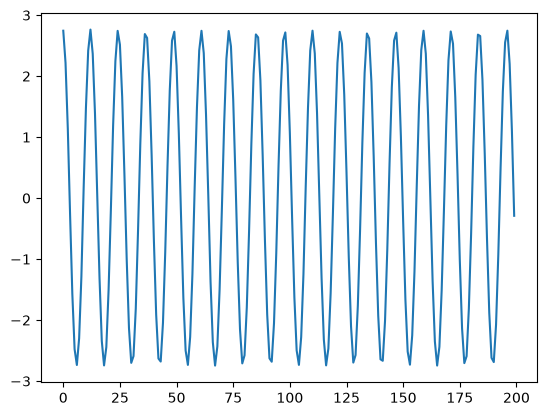

In [ ]:
read1,read2=np.array(meas)
def remove_zeroes(data):
    for i in range(len(data)):
        if data[i] < 0.04:
            data[i]=0
    return data

read1=remove_zeroes(read1)
read2=remove_zeroes(read2)
print(read1)
#plt.plot(read1*-1)
plt.plot(read2-read1)
#plt.plot(maximums)